In [1]:
#from google.colab import drive
#drive.mount('/content/drive')

In [2]:
import shutil
import pandas as pd
import random

import copy
import numpy as np # Import numpy for checking finite values
import matplotlib.pyplot as plt # Import matplotlib for potential debugging

import os
import math # Import math for ceil
from sklearn.manifold import TSNE # Import TSNE to check default perplexity



import os
import glob
import json
import numpy as np
import tensorflow as tf
import sys

In [3]:
import sys
fixed_path = 'C:\\Users\\admin\\0.Master_Thesis\\'
if fixed_path not in sys.path:
    sys.path.append(fixed_path)

old_cellcnn_path = f'{fixed_path}CellCNN/Old_CellCNN/'
if old_cellcnn_path not in sys.path:
    sys.path.append(old_cellcnn_path)

general_functions_path = f'{fixed_path}General_Functions/'
if general_functions_path not in sys.path:
    sys.path.append(general_functions_path)


In [4]:
decache_files = ['timepoints_elaboration', 'results_elaboration', 'new_datasets_generation', 'run_models',
                 'old_cellCnn.model', 'old_cellCnn.utils', 'old_cellCnn.downsample', 'old_cellCnn.model_grid' ]

# Rimuovi il modulo specifico dalla cache
from timepoints_elaboration import remove_from_cache
remove_from_cache(decache_files)


# import downloaded modules
from old_cellCnn.model import CellCnn

import old_cellCnn.utils as utils
import old_cellCnn.downsample as downsample

from timepoints_elaboration import load_data, donation_extraction, dataset_elaboration
from timepoints_elaboration import donor_division, patient_code_extraction, remove_from_cache

from results_elaboration import extract_hyper, phenotype_prediction, default_serializer, show_hyperparameters
from results_elaboration import elaborate_predictions, show_hyper

from run_models import trials_train_CellCNN, trials_test_CellCNN, trials_train_CellCNN_old, trials_test_CellCNN_old

from new_datasets_generation import splitting_and_dataset_elaboration

timepoints_elaboration rimosso dalla cache
results_elaboration non trovato nella cache
new_datasets_generation non trovato nella cache
old_cellCnn.model non trovato nella cache
old_cellCnn.utils non trovato nella cache
old_cellCnn.downsample non trovato nella cache
old_cellCnn.model_grid non trovato nella cache


# Import datasets from .csv

In [5]:
%%time

# Trova tutti i file con estensione specifica in una cartella
data_folder = f'{fixed_path}B-ALL_Datasets'
extension = '*.csv'  # cambia con l'estensione che ti serve

multiple_donations, ALL_DATASETS = load_data(data_path = data_folder, ext = extension)

Elaborating file 0: C:\Users\admin\0.Master_Thesis\B-ALL_Datasets\B-ALL_expression_matrix_220204-2900.csv
Elaborating file 1: C:\Users\admin\0.Master_Thesis\B-ALL_Datasets\B-ALL_expression_matrix_220208-3665.csv
Elaborating file 2: C:\Users\admin\0.Master_Thesis\B-ALL_Datasets\B-ALL_expression_matrix_220216-3546.csv
Elaborating file 3: C:\Users\admin\0.Master_Thesis\B-ALL_Datasets\B-ALL_expression_matrix_B-ALL_GHE11_D15_1.csv
Elaborating file 4: C:\Users\admin\0.Master_Thesis\B-ALL_Datasets\B-ALL_expression_matrix_B-ALL_GHE11_D29_1.csv
Elaborating file 5: C:\Users\admin\0.Master_Thesis\B-ALL_Datasets\B-ALL_expression_matrix_B-ALL_GHE11_D71_1.csv
Elaborating file 6: C:\Users\admin\0.Master_Thesis\B-ALL_Datasets\B-ALL_expression_matrix_B-ALL_GHE12_D15_2.csv
Elaborating file 7: C:\Users\admin\0.Master_Thesis\B-ALL_Datasets\B-ALL_expression_matrix_B-ALL_GHE12_D29_1.csv
Elaborating file 8: C:\Users\admin\0.Master_Thesis\B-ALL_Datasets\B-ALL_expression_matrix_B-ALL_GHE1_D15_2.csv
Elaborating

# Elaborate datasets

In [6]:
for i, dataset in enumerate(ALL_DATASETS):
    blast_n = (dataset['IsBlast'] == 1).sum()
    
    print(f'dataset {i} has {blast_n} cells over {len(dataset)} cells')

dataset 0 has 0 cells over 6558750 cells
dataset 1 has 0 cells over 2764877 cells
dataset 2 has 0 cells over 1291729 cells
dataset 3 has 1348 cells over 843500 cells
dataset 4 has 170 cells over 1404000 cells
dataset 5 has 0 cells over 3265250 cells
dataset 6 has 639 cells over 430869 cells
dataset 7 has 15 cells over 722000 cells
dataset 8 has 757 cells over 864000 cells
dataset 9 has 0 cells over 1947518 cells
dataset 10 has 308059 cells over 778750 cells
dataset 11 has 830101 cells over 5510750 cells
dataset 12 has 72 cells over 208000 cells
dataset 13 has 0 cells over 2912500 cells
dataset 14 has 3096 cells over 160500 cells
dataset 15 has 1449 cells over 3591480 cells
dataset 16 has 0 cells over 3107000 cells
dataset 17 has 9147 cells over 637409 cells
dataset 18 has 227 cells over 2928000 cells
dataset 19 has 518 cells over 164553 cells
dataset 20 has 398 cells over 191975 cells
dataset 21 has 0 cells over 169000 cells
dataset 22 has 2390 cells over 479000 cells
dataset 23 has 77

In [7]:
# Show patients donations
print(multiple_donations)

{'11': [3, 4, 5], '12': [6, 7], '1': [8, 9], '2': [10, 11], '3': [12, 13], '4': [14, 15, 16], '6': [17, 18], '7': [19, 20, 21], '8': [22, 23], '9': [24, 25], '13': [0], '14': [1], '15': [2]}


In [8]:
healthy_donors, blast_donors, mixed_donors = donor_division(multiple_donations, ALL_DATASETS)

print(healthy_donors, blast_donors, mixed_donors)

{'11': [1, 1, 0], '12': [1, 1], '1': [1, 0], '2': [1, 1], '3': [1, 0], '4': [1, 1, 0], '6': [1, 1], '7': [1, 1, 0], '8': [1, 1], '9': [1, 1], '13': [0], '14': [0], '15': [0]}
['12', '2', '6', '8', '9'] ['13', '14', '15'] ['11', '1', '3', '4', '7']


In [9]:

# Samples donors for Train, Validation and Test sets    
train_donors_idx, val_donors_idx, test_donors_idx = dataset_elaboration(multiple_donations, ALL_DATASETS, healthy_donors, blast_donors,
                        mixed_donors, seed = 42)



Precess starts. Dividing donors...
healthy_donors_idx, blast_donors_idx, mixed_donors_idx: [0, 4, 2, 1, 3], [0, 2, 1],[4, 0, 2, 1, 3]
Seting Train, Validation and Test idx...
['12', '9', '13', '7'] ['6', '15', '3'] ['2', '8', '14', '11', '1', '4']


In [10]:

#  Retrieves specific donor datasets from all datasets list
train_datasets_extracted = donation_extraction(train_donors_idx, multiple_donations, ALL_DATASETS)
val_datasets_extracted = donation_extraction(val_donors_idx, multiple_donations, ALL_DATASETS)
test_datasets_extracted = donation_extraction(test_donors_idx, multiple_donations, ALL_DATASETS)


print(len(train_datasets_extracted)) # list of donators
print(len(train_datasets_extracted[0])) # list of donations
print(len(test_datasets_extracted[0][0])) # dataset of cells

4
2
778750


In [11]:
n_sub = 3
seed = 42
n_cells = 100000
new_train_datasets, new_train_y, new_val_datasets, new_val_y, new_test_datasets, new_test_y = splitting_and_dataset_elaboration(train_datasets_extracted, 
                                                                                    val_datasets_extracted, test_datasets_extracted,
                                                                                    n_sub, n_cells, seed)



New training datasets creation...
4
2

New Donor
2
Tot blast data in the donor timepoints: 639
Tot blast data in the donor timepoints: 654
Extraction Done
Condition: 1
Chosen # of blast cells: [10000. 20000.  5000.]
Chosen # of blast cells: [ 5000. 10000. 20000.]

New Donor
2
Tot blast data in the donor timepoints: 44697
Tot blast data in the donor timepoints: 46110
Extraction Done
Condition: 1
Chosen # of blast cells: [20000.   500.  1000.]
Chosen # of blast cells: [  500.  1000. 20000.]

New Donor
1
Timepoint condition: Healthy
Extraction Done
Condition: 0

New Donor
3
Tot blast data in the donor timepoints: 518
Tot blast data in the donor timepoints: 916
Tot blast data in the donor timepoints: 916
Extraction Done
Condition: 1
Chosen # of blast cells: [10000. 10000. 20000.]
Chosen # of blast cells: [10000. 10000. 20000.]
[1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0]
Done!

New training datasets creation...

New Donor
Tot blast data in the donor timepoints: 9147
Tot 

In [12]:
for i, dataset in enumerate(new_test_datasets):
    blast_n = (dataset['IsBlast'] == 1).sum()
    
    print(f'dataset {i} has {blast_n} cells over {len(dataset)} cells. Label: {new_test_y[i]}')

dataset 0 has 500 cells over 100000 cells. Label: 1
dataset 1 has 5000 cells over 100000 cells. Label: 1
dataset 2 has 20000 cells over 100000 cells. Label: 1
dataset 3 has 0 cells over 100000 cells. Label: 0
dataset 4 has 0 cells over 100000 cells. Label: 0
dataset 5 has 0 cells over 100000 cells. Label: 0
dataset 6 has 500 cells over 100000 cells. Label: 1
dataset 7 has 500 cells over 100000 cells. Label: 1
dataset 8 has 10000 cells over 100000 cells. Label: 1
dataset 9 has 0 cells over 100000 cells. Label: 0
dataset 10 has 0 cells over 100000 cells. Label: 0
dataset 11 has 0 cells over 100000 cells. Label: 0
dataset 12 has 0 cells over 100000 cells. Label: 0
dataset 13 has 0 cells over 100000 cells. Label: 0
dataset 14 has 0 cells over 100000 cells. Label: 0
dataset 15 has 10000 cells over 100000 cells. Label: 1
dataset 16 has 20000 cells over 100000 cells. Label: 1
dataset 17 has 20000 cells over 100000 cells. Label: 1
dataset 18 has 0 cells over 100000 cells. Label: 0
dataset 19 h

In [13]:
print(len(new_train_datasets))
print(len(new_train_y))
print(len(new_val_datasets))
print(len(new_val_y))
print(len(new_test_datasets))
print(len(new_test_y))


21
21
15
15
33
33


In [14]:
original_test_datasets = []
original_test_y = []
for donor in test_datasets_extracted:
    for dataset in donor:

        if len(dataset[dataset['IsBlast'] == 1]) > 0:
            original_test_y.append(1)

        else:
            original_test_y.append(0)
        dataset = dataset.drop(columns = ['IsBlast'])
        original_test_datasets.append(dataset)
print(len(original_test_datasets))
print(original_test_y)

13
[1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0]


In [15]:
def remove_labels(new_test_datasets):
    new_no_label_test_datasets = []
    for dataset in new_test_datasets:
        dataset = dataset.drop(columns = ['IsBlast'])
        
        new_no_label_test_datasets.append(dataset)
    print(len(new_no_label_test_datasets))
    return new_no_label_test_datasets
new_no_label_test_datasets = remove_labels(new_test_datasets)
#print(new_no_label_test_datasets)

33


In [16]:
'''
def remove_isblast(datasets_list):
    new_train = []
    for dataset in datasets_list:
        new_train.append(dataset.drop(columns = ['IsBlast']))
    return new_train


new_val_datasets = remove_isblast(new_val_datasets)
new_train_datasets = remove_isblast(new_train_datasets)
new_test_datasets = remove_isblast(new_test_datasets)
'''

"\ndef remove_isblast(datasets_list):\n    new_train = []\n    for dataset in datasets_list:\n        new_train.append(dataset.drop(columns = ['IsBlast']))\n    return new_train\n\n\nnew_val_datasets = remove_isblast(new_val_datasets)\nnew_train_datasets = remove_isblast(new_train_datasets)\nnew_test_datasets = remove_isblast(new_test_datasets)\n"

In [41]:
decache_files = ['timepoints_elaboration', 'results_elaboration', 'new_datasets_generation', 'run_models',
                 'old_cellCnn.model', 'old_cellCnn.utils', 'old_cellCnn.downsample']

# Rimuovi il modulo specifico dalla cache
from timepoints_elaboration import remove_from_cache
remove_from_cache(decache_files)


# import downloaded modules
from old_cellCnn.model import CellCnn

import old_cellCnn.utils as utils
import old_cellCnn.downsample as downsample

from timepoints_elaboration import load_data, donation_extraction, dataset_elaboration
from timepoints_elaboration import donor_division, patient_code_extraction, remove_from_cache

from results_elaboration import extract_hyper, phenotype_prediction, default_serializer, show_hyperparameters
from results_elaboration import elaborate_predictions, show_hyper

from run_models import trials_train_CellCNN, trials_test_CellCNN, trials_train_CellCNN_old, trials_test_CellCNN_old

from new_datasets_generation import splitting_and_dataset_elaboration

timepoints_elaboration rimosso dalla cache
results_elaboration rimosso dalla cache
new_datasets_generation rimosso dalla cache
run_models rimosso dalla cache
old_cellCnn.model rimosso dalla cache
old_cellCnn.utils rimosso dalla cache
old_cellCnn.downsample rimosso dalla cache


# CellCNN OLD

In [33]:
%%time
seed_list = [7359, 9654, 4557, 106, 2615, 6924, 5574, 4552, 2547, 3527]

nfilter = [3,5,7,9]
maxpool_p = [1., 5., 20., 100.]
learning_r = [0.01, 0.001]
hyper = (nfilter, maxpool_p, learning_r)

def grid_or_rand_model(grid):
    if grid:
        remove_from_cache(['old_cellCnn.model_grid'])
        from old_cellCnn.model_grid import CellCnn
    else:
        remove_from_cache(['old_cellCnn.model'])
        from old_cellCnn.model import CellCnn
    return CellCnn

CPU times: total: 0 ns
Wall time: 0 ns


In [35]:
%%time
trials = 2

predictions_list, results_list = [], []
original_predictions_list = []
seed_list = [7359, 9654, 4557, 106, 2615, 6924, 5574, 4552, 2547, 3527]
resampled = []

#new_train_datasets_no_labels = remove_labels(new_train_datasets)
#new_val_datasets_no_labels = remove_labels(new_val_datasets)
new_no_label_test_datasets = remove_labels(new_test_datasets)

grid = True
CellCnn = grid_or_rand_model(grid)
if grid:
    train = remove_labels(new_train_datasets)
    val = remove_labels(new_val_datasets)
else:
    train = new_train_datasets
    val = new_val_datasets
    
test = remove_labels(new_test_datasets)

models_lists = trials_train_CellCNN_old(CellCnn, train, #new_train_datasets_no_labels, 
                              new_train_y, 
                              val, #new_val_datasets_no_labels, 
                              new_val_y, test, trials = trials,
                              n_cell = 10, max_epochs=1, nrun=1, seed_list = seed_list, hyper = hyper)

'''
for i in range(trials):
    print(f'\nTrial: {i}')
    seed = seed_list[i]
    model = train_CellCNN_old(CellCnn, train, #new_train_datasets_no_labels, 
                              new_train_y, 
                              val, #new_val_datasets_no_labels, 
                              new_val_y, test,
                              n_cell = 10, max_epochs=1, nrun=1,  seed = seed, hyper = hyper)

    prediction, result = test_CellCNN_old(model, new_no_label_test_datasets)
    predictions_list.append(prediction)
    results_list.append(result)

    original_prediction, result = test_CellCNN_old(model, original_test_datasets)
    original_predictions_list.append(original_prediction)
'''

33
old_cellCnn.model_grid rimosso dalla cache
21
15
33
Trial 1 started
Seed used: 7359
Model defined...
Fitting started...
21
21
[1 1 1 0 0 0 1 1 1 0 0 0 0 0 0 1 1 1 0 0 0]
11
11
10
10
(3, 1.0, 0.01)
(3, 1.0, 0.001)
(3, 5.0, 0.01)
(3, 5.0, 0.001)
(3, 20.0, 0.01)
(3, 20.0, 0.001)
(3, 100.0, 0.01)
(3, 100.0, 0.001)
(5, 1.0, 0.01)
(5, 1.0, 0.001)
(5, 5.0, 0.01)
(5, 5.0, 0.001)
(5, 20.0, 0.01)
(5, 20.0, 0.001)
(5, 100.0, 0.01)
(5, 100.0, 0.001)
(7, 1.0, 0.01)
(7, 1.0, 0.001)
(7, 5.0, 0.01)
(7, 5.0, 0.001)
(7, 20.0, 0.01)
(7, 20.0, 0.001)
(7, 100.0, 0.01)
(7, 100.0, 0.001)
(9, 1.0, 0.01)
(9, 1.0, 0.001)
(9, 5.0, 0.01)
(9, 5.0, 0.001)
(9, 20.0, 0.01)
(9, 20.0, 0.001)
(9, 100.0, 0.01)
(9, 100.0, 0.001)
Total number of selections: 32

# ============================================= #
Run: 0

Seed: 7359
Adopted Parameters: (3, 1.0, 0.01)
10
10
24/24 [==============================] - 0s 2ms/step - loss: 0.6816 - accuracy: 0.6000

# ============================================= #
Run: 1

Seed: 7

C:\Users\admin\anaconda3\envs\tf_env\lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
C:\Users\admin\anaconda3\envs\tf_env\lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
C:\Users\admin\anaconda3\envs\tf_env\lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
C:\Users\admin\anaconda3\envs\tf_env\lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
C:\Users\admin\anaconda3\envs\tf_env\lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
C:\Users\admin\anaconda3\envs\tf_env\lib

Trial 2 started
Seed used: 19308
Model defined...
Fitting started...
21
21
[1 1 1 0 0 0 1 1 1 0 0 0 0 0 0 1 1 1 0 0 0]
11
11
10
10
(3, 1.0, 0.01)
(3, 1.0, 0.001)
(3, 5.0, 0.01)
(3, 5.0, 0.001)
(3, 20.0, 0.01)
(3, 20.0, 0.001)
(3, 100.0, 0.01)
(3, 100.0, 0.001)
(5, 1.0, 0.01)
(5, 1.0, 0.001)
(5, 5.0, 0.01)
(5, 5.0, 0.001)
(5, 20.0, 0.01)
(5, 20.0, 0.001)
(5, 100.0, 0.01)
(5, 100.0, 0.001)
(7, 1.0, 0.01)
(7, 1.0, 0.001)
(7, 5.0, 0.01)
(7, 5.0, 0.001)
(7, 20.0, 0.01)
(7, 20.0, 0.001)
(7, 100.0, 0.01)
(7, 100.0, 0.001)
(9, 1.0, 0.01)
(9, 1.0, 0.001)
(9, 5.0, 0.01)
(9, 5.0, 0.001)
(9, 20.0, 0.01)
(9, 20.0, 0.001)
(9, 100.0, 0.01)
(9, 100.0, 0.001)
Total number of selections: 32

# ============================================= #
Run: 0

Seed: 19308
Adopted Parameters: (3, 1.0, 0.01)
10
10
24/24 [==============================] - 0s 2ms/step - loss: 0.6770 - accuracy: 0.6000

# ============================================= #
Run: 1

Seed: 19309
Adopted Parameters: (3, 1.0, 0.001)
10
10
24/24 

C:\Users\admin\anaconda3\envs\tf_env\lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
C:\Users\admin\anaconda3\envs\tf_env\lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
C:\Users\admin\anaconda3\envs\tf_env\lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
C:\Users\admin\anaconda3\envs\tf_env\lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
C:\Users\admin\anaconda3\envs\tf_env\lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
C:\Users\admin\anaconda3\envs\tf_env\lib

Trial 3 started
Seed used: 13671
Model defined...
Fitting started...
21
21
[1 1 1 0 0 0 1 1 1 0 0 0 0 0 0 1 1 1 0 0 0]
11
11
10
10
(3, 1.0, 0.01)
(3, 1.0, 0.001)
(3, 5.0, 0.01)
(3, 5.0, 0.001)
(3, 20.0, 0.01)
(3, 20.0, 0.001)
(3, 100.0, 0.01)
(3, 100.0, 0.001)
(5, 1.0, 0.01)
(5, 1.0, 0.001)
(5, 5.0, 0.01)
(5, 5.0, 0.001)
(5, 20.0, 0.01)
(5, 20.0, 0.001)
(5, 100.0, 0.01)
(5, 100.0, 0.001)
(7, 1.0, 0.01)
(7, 1.0, 0.001)
(7, 5.0, 0.01)
(7, 5.0, 0.001)
(7, 20.0, 0.01)
(7, 20.0, 0.001)
(7, 100.0, 0.01)
(7, 100.0, 0.001)
(9, 1.0, 0.01)
(9, 1.0, 0.001)
(9, 5.0, 0.01)
(9, 5.0, 0.001)
(9, 20.0, 0.01)
(9, 20.0, 0.001)
(9, 100.0, 0.01)
(9, 100.0, 0.001)
Total number of selections: 32

# ============================================= #
Run: 0

Seed: 13671
Adopted Parameters: (3, 1.0, 0.01)
10
10
24/24 [==============================] - 0s 2ms/step - loss: 0.6799 - accuracy: 0.6000

# ============================================= #
Run: 1

Seed: 13672
Adopted Parameters: (3, 1.0, 0.001)
10
10
24/24 

...

Trial 9 started
Seed used: 22923
Model defined...
Fitting started...
21
21
[1 1 1 0 0 0 1 1 1 0 0 0 0 0 0 1 1 1 0 0 0]
11
11
10
10
(3, 1.0, 0.01)
(3, 1.0, 0.001)
(3, 5.0, 0.01)
(3, 5.0, 0.001)
(3, 20.0, 0.01)
(3, 20.0, 0.001)
(3, 100.0, 0.01)
(3, 100.0, 0.001)
(5, 1.0, 0.01)
(5, 1.0, 0.001)
(5, 5.0, 0.01)
(5, 5.0, 0.001)
(5, 20.0, 0.01)
(5, 20.0, 0.001)
(5, 100.0, 0.01)
(5, 100.0, 0.001)
(7, 1.0, 0.01)
(7, 1.0, 0.001)
(7, 5.0, 0.01)
(7, 5.0, 0.001)
(7, 20.0, 0.01)
(7, 20.0, 0.001)
(7, 100.0, 0.01)
(7, 100.0, 0.001)
(9, 1.0, 0.01)
(9, 1.0, 0.001)
(9, 5.0, 0.01)
(9, 5.0, 0.001)
(9, 20.0, 0.01)
(9, 20.0, 0.001)
(9, 100.0, 0.01)
(9, 100.0, 0.001)
Total number of selections: 32

# ============================================= #
Run: 0

Seed: 22923
Adopted Parameters: (3, 1.0, 0.01)
10
10
24/24 [==============================] - 0s 2ms/step - loss: 0.6787 - accuracy: 0.6000

# ============================================= #
Run: 1

Seed: 22924
Adopted Parameters: (3, 1.0, 0.001)
10
10
24/24 

C:\Users\admin\anaconda3\envs\tf_env\lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
C:\Users\admin\anaconda3\envs\tf_env\lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
C:\Users\admin\anaconda3\envs\tf_env\lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
C:\Users\admin\anaconda3\envs\tf_env\lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
C:\Users\admin\anaconda3\envs\tf_env\lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
C:\Users\admin\anaconda3\envs\tf_env\lib

Trial 10 started
Seed used: 35270
Model defined...
Fitting started...
21
21
[1 1 1 0 0 0 1 1 1 0 0 0 0 0 0 1 1 1 0 0 0]
11
11
10
10
(3, 1.0, 0.01)
(3, 1.0, 0.001)
(3, 5.0, 0.01)
(3, 5.0, 0.001)
(3, 20.0, 0.01)
(3, 20.0, 0.001)
(3, 100.0, 0.01)
(3, 100.0, 0.001)
(5, 1.0, 0.01)
(5, 1.0, 0.001)
(5, 5.0, 0.01)
(5, 5.0, 0.001)
(5, 20.0, 0.01)
(5, 20.0, 0.001)
(5, 100.0, 0.01)
(5, 100.0, 0.001)
(7, 1.0, 0.01)
(7, 1.0, 0.001)
(7, 5.0, 0.01)
(7, 5.0, 0.001)
(7, 20.0, 0.01)
(7, 20.0, 0.001)
(7, 100.0, 0.01)
(7, 100.0, 0.001)
(9, 1.0, 0.01)
(9, 1.0, 0.001)
(9, 5.0, 0.01)
(9, 5.0, 0.001)
(9, 20.0, 0.01)
(9, 20.0, 0.001)
(9, 100.0, 0.01)
(9, 100.0, 0.001)
Total number of selections: 32

# ============================================= #
Run: 0

Seed: 35270
Adopted Parameters: (3, 1.0, 0.01)
10
10
24/24 [==============================] - 0s 6ms/step - loss: 0.6793 - accuracy: 0.6000

# ============================================= #
Run: 1

Seed: 35271
Adopted Parameters: (3, 1.0, 0.001)
10
10
24/24

C:\Users\admin\anaconda3\envs\tf_env\lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
C:\Users\admin\anaconda3\envs\tf_env\lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
C:\Users\admin\anaconda3\envs\tf_env\lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
C:\Users\admin\anaconda3\envs\tf_env\lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
C:\Users\admin\anaconda3\envs\tf_env\lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
C:\Users\admin\anaconda3\envs\tf_env\lib

TypeError: object of type 'CellCnn' has no len()

In [43]:
print(len(models_lists))

predictions_list, results_list = trials_test_CellCNN_old(models_lists, new_no_label_test_datasets)

original_predictions_list, original_results_list = trials_test_CellCNN_old(models_lists, original_test_datasets)

10
10
Prediction started...


C:\Users\admin\anaconda3\envs\tf_env\lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
C:\Users\admin\anaconda3\envs\tf_env\lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
C:\Users\admin\anaconda3\envs\tf_env\lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
C:\Users\admin\anaconda3\envs\tf_env\lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
C:\Users\admin\anaconda3\envs\tf_env\lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
C:\Users\admin\anaconda3\envs\tf_env\lib

2/2 [==============================] - 2s 54ms/step
Done
Trial 1 Done!

10
Prediction started...


C:\Users\admin\anaconda3\envs\tf_env\lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
C:\Users\admin\anaconda3\envs\tf_env\lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
C:\Users\admin\anaconda3\envs\tf_env\lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
C:\Users\admin\anaconda3\envs\tf_env\lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
C:\Users\admin\anaconda3\envs\tf_env\lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
C:\Users\admin\anaconda3\envs\tf_env\lib

2/2 [==============================] - 1s 28ms/step
Done
Trial 2 Done!

10
Prediction started...


...

1/1 [==============================] - 0s 376ms/step
Done
Trial 8 Done!

10
Prediction started...


C:\Users\admin\anaconda3\envs\tf_env\lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
C:\Users\admin\anaconda3\envs\tf_env\lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
C:\Users\admin\anaconda3\envs\tf_env\lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
C:\Users\admin\anaconda3\envs\tf_env\lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
C:\Users\admin\anaconda3\envs\tf_env\lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
C:\Users\admin\anaconda3\envs\tf_env\lib

1/1 [==============================] - 0s 258ms/step
Done
Trial 9 Done!

10
Prediction started...


C:\Users\admin\anaconda3\envs\tf_env\lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
C:\Users\admin\anaconda3\envs\tf_env\lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
C:\Users\admin\anaconda3\envs\tf_env\lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
C:\Users\admin\anaconda3\envs\tf_env\lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
C:\Users\admin\anaconda3\envs\tf_env\lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
C:\Users\admin\anaconda3\envs\tf_env\lib

1/1 [==============================] - 0s 216ms/step
Done
Trial 10 Done!



In [21]:
model_setting = 0
import json

save_path = f'{fixed_path}CellCNN\\results\\old\\'
with open(f'{save_path}old_results_list{model_setting}.json', "w", encoding="utf-8") as f:
    json.dump(tot_trials_res, f, default=default_serializer, ensure_ascii=False, indent=2)

with open(f'{save_path}old_predictions_list{model_setting}.json', "w", encoding="utf-8") as f:
    json.dump(predictions_list, f, default=default_serializer, ensure_ascii=False, indent=2)

with open(f'{save_path}old_test_y{model_setting}.json', "w", encoding="utf-8") as f:
    json.dump(new_test_y, f, default=default_serializer, ensure_ascii=False, indent=2)

with open(f'{save_path}original_old_predictions_list{model_setting}.json', "w", encoding="utf-8") as f:
    json.dump(original_predictions_list, f, default=default_serializer, ensure_ascii=False, indent=2)

with open(f'{save_path}original_old_test_y{model_setting}.json', "w", encoding="utf-8") as f:
    json.dump(original_test_y, f, default=default_serializer, ensure_ascii=False, indent=2)
    
'''
with open(f'{save_path}old_predictions_list.json', "r", encoding="utf-8") as f:
    imported_test_pred = json.load(f)

with open(f'{save_path}old_results_list.json', "r", encoding="utf-8") as f:
    imported_old_results = json.load(f)

with open(f'{save_path}old_test_y.json', "r", encoding="utf-8") as f:
    imported_old_test_y = json.load(f)
'''

'\nwith open(f\'{save_path}old_predictions_list.json\', "r", encoding="utf-8") as f:\n    imported_test_pred = json.load(f)\n\nwith open(f\'{save_path}old_results_list.json\', "r", encoding="utf-8") as f:\n    imported_old_results = json.load(f)\n\nwith open(f\'{save_path}old_test_y.json\', "r", encoding="utf-8") as f:\n    imported_old_test_y = json.load(f)\n'

In [44]:
original_best_per_trial = show_hyper(results_list, best_3 = False)
print(original_best_per_trial)
 

   nfilter  learning_rate  maxpool_percentage
0      5.0           0.01                 1.0
1      9.0           0.01                20.0
2      5.0           0.01                20.0
3      5.0           0.01                 5.0
4      9.0           0.01                 5.0
5      5.0           0.01                 1.0
6      9.0           0.01                 5.0
7      5.0           0.01                 1.0
8      5.0           0.01                 1.0
9      5.0           0.01                20.0


'\n   nfilter  learning_rate  maxpool_percentage\n0      5.0          0.010                20.0\n1      3.0          0.001                20.0\n\n   nfilter  learning_rate  maxpool_percentage\n0      5.0           0.01                 1.0\n1      3.0           0.01                20.0\n'

In [45]:
pred_phenotype_df, accuracy_list = elaborate_predictions(predictions_list, new_test_y, results = True)

Trial 0 Accuracy: 0.5454545454545454
Trial 1 Accuracy: 0.5454545454545454
Trial 2 Accuracy: 0.5454545454545454
Trial 3 Accuracy: 0.5454545454545454
Trial 4 Accuracy: 0.6060606060606061
Trial 5 Accuracy: 0.5454545454545454
Trial 6 Accuracy: 0.5454545454545454
Trial 7 Accuracy: 0.5454545454545454
Trial 8 Accuracy: 0.5454545454545454
Trial 9 Accuracy: 0.5454545454545454
             0   1   2   3   4   5   6   7   8   9   ...  23  24  25  26  27  \
0             0   0   0   0   0   0   0   0   0   0  ...   0   0   0   0   0   
1             0   0   0   0   0   0   0   0   0   0  ...   0   0   0   0   0   
2             0   0   0   0   0   0   0   0   0   0  ...   0   0   0   0   0   
3             0   0   0   0   0   0   0   0   0   0  ...   0   0   0   0   0   
4             0   0   0   0   0   0   0   0   0   0  ...   0   0   0   0   0   
5             0   0   0   0   0   0   0   0   0   0  ...   0   0   0   0   0   
6             0   0   0   0   0   0   0   0   0   0  ...   0   0   0  

In [24]:
original_pred_phenotype_df, original_accuracy_list = elaborate_predictions(original_predictions_list, original_test_y, results = True)

Trial 0 Accuracy: 0.3076923076923077
Trial 1 Accuracy: 0.3076923076923077
             0   1   2   3   4   5   6   7   8   9   10  11  12
0             0   0   0   0   0   0   0   0   0   0   0   0   0
1             0   0   0   0   0   0   0   0   0   0   0   0   0
True Labels   1   1   1   1   0   1   1   0   1   0   1   1   0
mean_accuracy over the ten trials: 0.3076923076923077
accuracy_std over the ten trials: 0.0


In [25]:
test_blast_perc = []
for ds in new_test_datasets:
    bc = len(ds[ds['IsBlast'] == 1])*100

    test_blast_perc.append(bc/len(ds))
print(np.array(test_blast_perc))

[ 0.5  5.  20.   0.   0.   0.   0.5  0.5 10.   0.   0.   0.   0.   0.
  0.  10.  20.  20.   0.   0.   0.   1.  10.  20.   0.   0.   0.   0.5
  1.   5.   0.   0.   0. ]


In [26]:
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score, roc_curve
def plot_roc_curve(true_y, y_prob):
    """
    plots the roc curve based of the probabilities
    """

    fpr, tpr, thresholds = roc_curve(true_y, y_prob)
    plt.plot(fpr, tpr)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    


[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
[1 1 1 0 0 0 1 1 1 0 0 0 0 0 0 1 1 1 0 0 0 1 1 1 0 0 0 1 1 1 0 0 0]
[0.5, 5.0, 20.0, 0.0, 0.0, 0.0, 0.5, 0.5, 10.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 10.0, 20.0, 20.0, 0.0, 0.0, 0.0, 1.0, 10.0, 20.0, 0.0, 0.0, 0.0, 0.5, 1.0, 5.0, 0.0, 0.0, 0.0]
Confusion matrix
[[18  0]
 [15  0]]



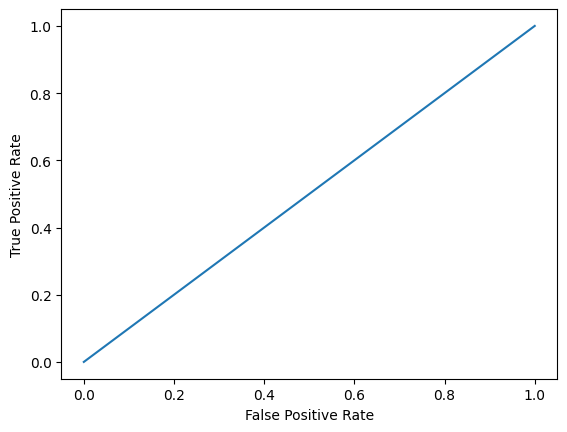

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
[1 1 1 0 0 0 1 1 1 0 0 0 0 0 0 1 1 1 0 0 0 1 1 1 0 0 0 1 1 1 0 0 0]
[0.5, 5.0, 20.0, 0.0, 0.0, 0.0, 0.5, 0.5, 10.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 10.0, 20.0, 20.0, 0.0, 0.0, 0.0, 1.0, 10.0, 20.0, 0.0, 0.0, 0.0, 0.5, 1.0, 5.0, 0.0, 0.0, 0.0]
Confusion matrix
[[18  0]
 [15  0]]



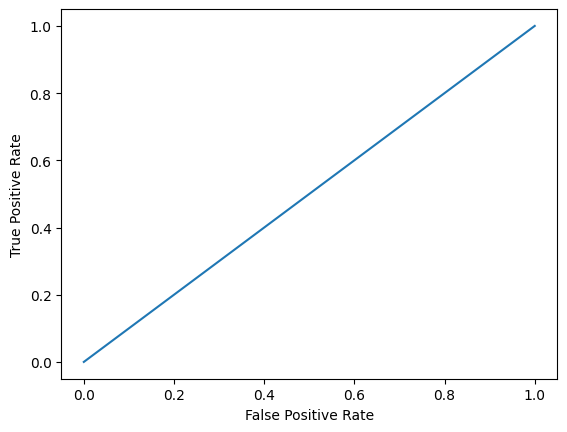

[1 1 1 0 0 0 1 1 1 0 0 0 0 0 0 1 1 1 0 0 0 1 1 1 0 0 0 1 1 1 0 0 0]
[1 1 1 0 0 0 1 1 1 0 0 0 0 0 0 1 1 1 0 0 0 1 1 1 0 0 0 1 1 1 0 0 0]
[0.5, 5.0, 20.0, 0.0, 0.0, 0.0, 0.5, 0.5, 10.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 10.0, 20.0, 20.0, 0.0, 0.0, 0.0, 1.0, 10.0, 20.0, 0.0, 0.0, 0.0, 0.5, 1.0, 5.0, 0.0, 0.0, 0.0]
Confusion matrix
[[18  0]
 [ 0 15]]



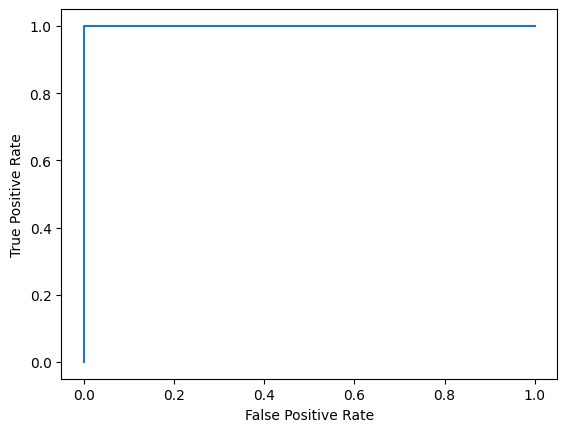

In [27]:

for trial in pred_phenotype_df.values:
    print(trial)
    print(np.array(new_test_y))
    print(test_blast_perc)
    cf_mat = confusion_matrix(new_test_y, trial)
    print('Confusion matrix')
    print(cf_mat)
    print('')
    plot_roc_curve(new_test_y, trial)
    plt.show()

In [28]:
15, 2000

'''Study resampling labels'''

resampled = []
y_labels_resampled = []
for res in results_list:
    for key, value in res.items():
        if key == 'resampled':
            resampled.append(value)
        if key == 'y_labels_resampled':
            y_labels_resampled.append(value)

print(len(resampled))
labels = []
for i in range(len(resampled)):
    for key, value in resampled[i].items():
        for sample in value:
            labels.append(sample[-1])

#print(len(labels))
y_labels = []
for i in range(len(y_labels_resampled)):
    for element in y_labels_resampled[i]:
        for lab in element:
            y_labels.append(lab)
#print(y_labels)
    
true_labels = []
for cells_labels in labels:
    cells_labels.sum()
    if cells_labels.sum() > 0:
        true_labels.append(1)
    else:
        true_labels.append(0)

    

#print(true_labels)

correct = 0
incorrect = 0
for true_l, y_l in zip(true_labels, y_labels):
    if true_l == y_l:
        correct += 1
    else:
        incorrect += 1
print(f'Correctly labeled: {correct}. Incorrect: {incorrect}')

cf_mat_resampled_labels = confusion_matrix(true_labels, y_labels)
print(cf_mat_resampled_labels)


0
Correctly labeled: 0. Incorrect: 0
[]
